In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

#TensorFlow is Google's deep learning framework.
import tensorflow as tf
# Layers - Used to create neural network layers such as Dense, Conv2D, Dropout, etc.
from tensorflow.keras import layers

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

import keras
#Loads the built-in MNIST handwritten digit dataset.
from keras.datasets import mnist
#Converts integer labels into one-hot encoded vectors.
from keras.utils import to_categorical

In [2]:
#!pip install keras

In [3]:
#!pip install tensorflow

# Load Dataset

In [4]:
(X_train, Y_train), (X_test, Y_test) =mnist.load_data()

In [5]:
#X_train = (60000,28,28)

#Y_train = (60000)

#X_test = (10000,28,28)

#Y_test = (10000)

# image - 28 × 28 pixels

# Display Sample Images

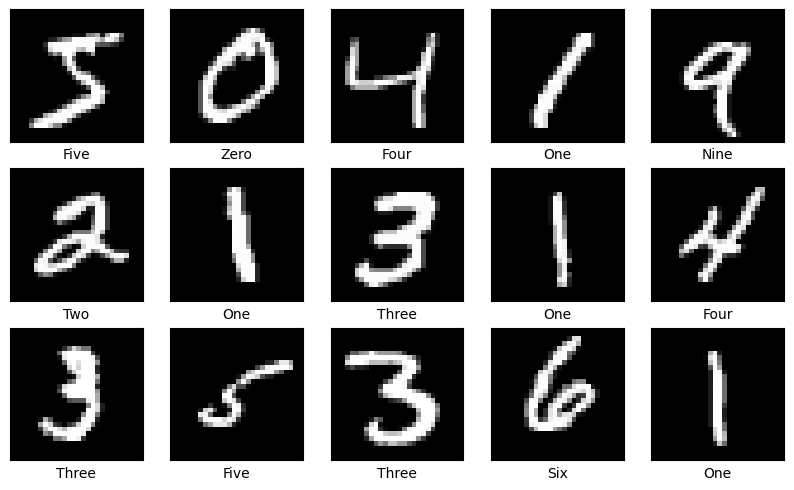

In [6]:
col_names=['Zero', 'One', 'Two', 'Three','Four', 'Five', 'Six','Seven', 'Eight', 'Nine']
plt.figure(figsize =(10,10))
for i in range(15):
    plt.subplot(5,5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train[i], cmap='gray')
    plt.xlabel(col_names[Y_train[i]])
plt.show()

In [7]:
X_train.shape

(60000, 28, 28)

In [8]:
Y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

# Reshape Images

In [9]:
X_train = X_train.reshape(60000, 784)
X_test =  X_test.reshape(10000, 784)

In [10]:
X_train.shape

(60000, 784)

In [11]:
Y_test

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8)

In [12]:
# Find out how many class present in label
len(np.unique(Y_train))

10

In [13]:
X_train[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

In [14]:
Y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

# One-Hot Encoding the Labels

In [15]:
Y_train = to_categorical(Y_train, num_classes=10)
Y_test= to_categorical(Y_test, num_classes = 10)

In [16]:
Y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(60000, 10))

In [17]:
Y_test

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10000, 10))

# Build the Artificial Neural Network (ANN)

In [18]:
# Sequential means the layers are connected one after another. input -> hidden layer1 -> Hidden layer2--> output
model = keras.Sequential([
    #First Hidden Layer
    #Dense layer -  every neuron connects to every neuron in the previous layer. here 256 neurons. input is 784
    #ReLU(x)=max(0,x) 
    # activation - Helps the network learn complex patterns. relu for hidden layer
    layers.Dense(256, activation='relu', input_shape=(784,)),

    #Creates another hidden layer with 64 neurons
    layers.Dense(64, activation='relu'),

     #Creates another hidden layer with 64 neurons
    layers.Dense(64, activation='relu'),
    
    #Creates the 10 output layer. Binary Classification -sigmoid 
    layers.Dense(10, activation='sigmoid')
])

C:\Anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Displays the model architecture.

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 222,218 (868.04 KB)

 Trainable params: 222,218 (868.04 KB)

 Non-trainable params: 0 (0.00 B)

# Compile the Model and Before training, Keras needs three things.

In [20]:
# loss="categorical_crossentropy" - Measures how wrong the predictions are. Lower loss means better predictions.
# optimizer="adam" - updates the weights after every batch
# metrics=["accuracy"] - Displays accuracy while training.

model.compile(loss="categorical_crossentropy", optimizer ="adam", metrics =['accuracy'])

# Train the Model 
# validation_data - After every epoch, the model is tested using unseen data.
# Epochs - model repeatedly learn from the entire training dataset so it can gradually improve its weights, reduce prediction errors, and increase accuracy.

In [21]:
history = model.fit(X_train, Y_train, batch_size=100, epochs=20, validation_data=(X_test,Y_test))

Epoch 1/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.8224 - loss: 1.5598 - val_accuracy: 0.9024 - val_loss: 0.3460
Epoch 2/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9103 - loss: 0.2567 - val_accuracy: 0.9290 - val_loss: 0.2445
Epoch 3/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9320 - loss: 0.1808 - val_accuracy: 0.9106 - val_loss: 0.2115
Epoch 4/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9357 - loss: 0.1484 - val_accuracy: 0.9353 - val_loss: 0.1896
Epoch 5/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9393 - loss: 0.1246 - val_accuracy: 0.9173 - val_loss: 0.1688
Epoch 6/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9334 - loss: 0.1032 - val_accuracy: 0.9170 - val_loss: 0.1706
Epoch 7/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9198 - loss: 0.1001 - val_accuracy: 0.8885 - val_loss: 0.1578
Epoch 8/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9270 - loss: 0.0901 - val_a

In [22]:
X_train.shape

(60000, 784)

# Evaluates loss and accuracy from the trained model

In [23]:
# Here batch_size default value is 32 and if not mentioned it will reflect batch size as 32
test_loss_digit, test_acc_digit = model.evaluate(X_test, Y_test, batch_size=32)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9043 - loss: 0.1114


In [24]:
print('Digit MNIST Test accuracy:', round(test_acc_digit,2))

Digit MNIST Test accuracy: 0.9


# Predicts all test images

In [25]:
Y_pred = model.predict(X_test, batch_size=100)

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [26]:
X_test

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(10000, 784), dtype=uint8)

In [27]:
Y_pred[0]

array([2.1448855e-04, 3.5733429e-01, 6.2918139e-01, 8.5505894e-07,
       2.7674329e-01, 3.7695133e-04, 7.2488874e-08, 9.9999988e-01,
       7.9882284e-06, 4.4166720e-01], dtype=float32)

# Finds the index with the largest probability and Converts one-hot encoded labels back to integers.

In [28]:
Y_predict = np.argmax(Y_pred, axis=1)
Y_test_eval= np.argmax(Y_test,axis=1)

In [29]:
Y_predict[0]

np.int64(7)

In [30]:
Y_test_eval

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [31]:
y_pre=pd.DataFrame(Y_predict)
y_pre

,0
0,7
1,2
2,1
3,0
4,4
...,...
9995,2
9996,3
9997,4
9998,5


# Creates a confusion matrix. Diagonal values are correct predictions.Off-diagonal values are mistakes. Displays the confusion matrix as a heatmap.

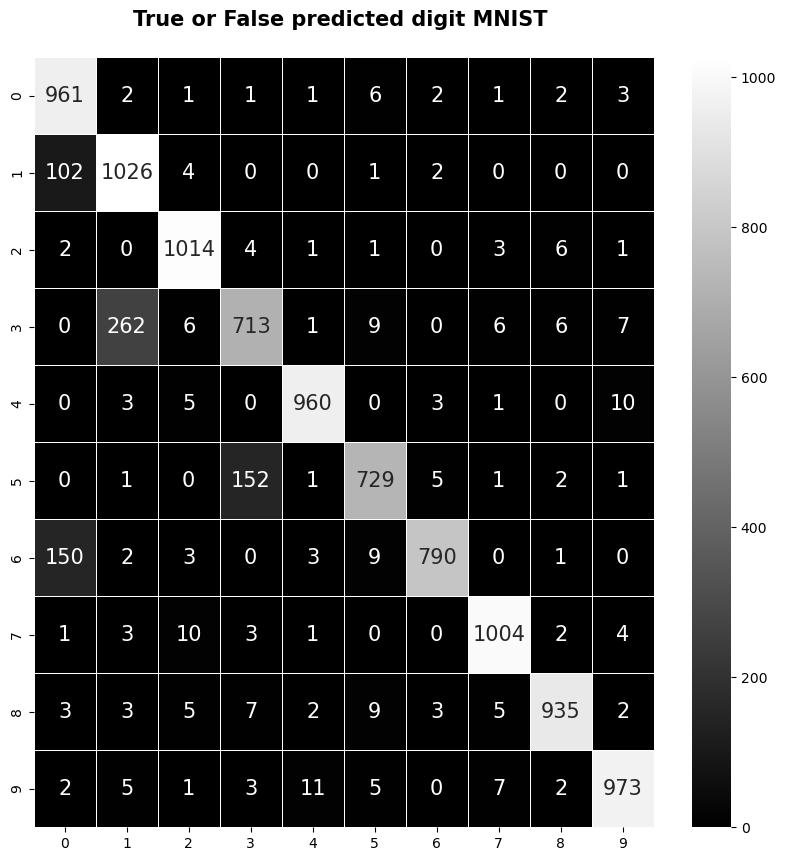

In [32]:
con_mat = confusion_matrix(Y_test_eval, Y_predict)
plt.style.use('seaborn-v0_8-deep')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat, annot =True, annot_kws={'size':15}, linewidths=0.5, fmt="d", cmap="gray")
plt.title('True or False predicted digit MNIST \n', fontweight ='bold', fontsize =15)
plt.show()

# Show the Classification Report

In [33]:
from sklearn.metrics import classification_report

print(classification_report(Y_test_eval,Y_predict))

              precision    recall  f1-score   support

           0       0.79      0.98      0.87       980
           1       0.79      0.90      0.84      1135
           2       0.97      0.98      0.97      1032
           3       0.81      0.71      0.75      1010
           4       0.98      0.98      0.98       982
           5       0.95      0.82      0.88       892
           6       0.98      0.82      0.90       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.96      0.97       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.91     10000
   macro avg       0.92      0.91      0.91     10000
weighted avg       0.92      0.91      0.91     10000



# Shows the metrics stored during training.

In [34]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


# Draw Accuracy Graph

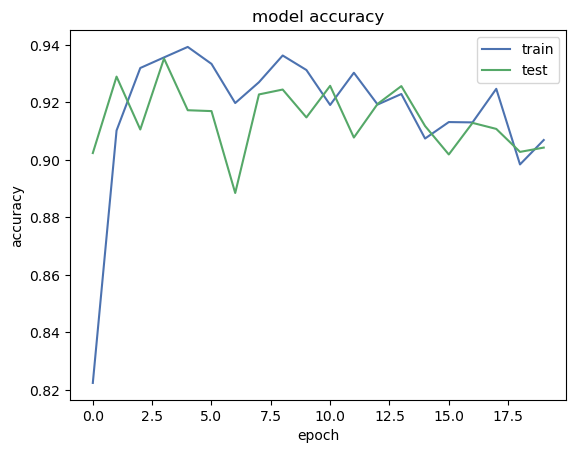

In [35]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()


# Draw Loss Graph

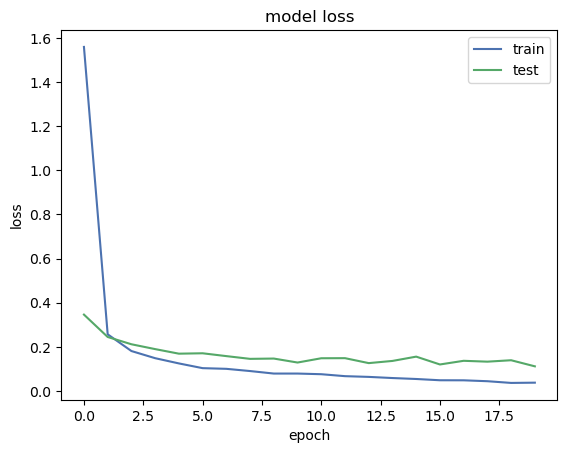

In [36]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

# Predict single Image how it is working first

In [37]:
# Predicts only the third test image
j=2
y_predict_single = model.predict(X_test[[j]])

#Finds the predicted digit.
y_predicts_single=np.argmax(y_predict_single, axis=1)

#Converts all one-hot encoded test labels back to integer labels.
Y_test=np.argmax(Y_test, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


In [38]:
y_predicts_single[0]

np.int64(1)

# Display Prediction

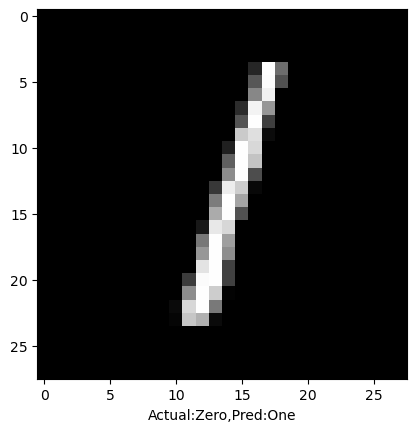

In [39]:
#Names of numbers in the dataset in order
col_names = ['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

#Visualizing the digits
#Reshapes the flattened image (784 pixels) back to its original 28 × 28 form and displays it.
plt.imshow(X_test[j].reshape(28,28), cmap='gray')

#Shows both the actual and predicted digit below the image.
plt.xlabel("Actual:{},Pred:{}".format(col_names[np.argmax(Y_test[j])],col_names[y_predicts_single[0]]))
plt.show()

In [40]:
np.argmax(Y_test[j])

np.int64(0)

In [41]:
Y_test[j]

np.int64(1)

In [42]:
col_names[y_predicts_single[0]]

'One'